In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.datasets import fashion_mnist

In [3]:
# (train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [4]:
train_images.ndim

3

In [5]:
train_images.shape

(60000, 28, 28)

In [6]:
train_labels.shape

(60000,)

In [7]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

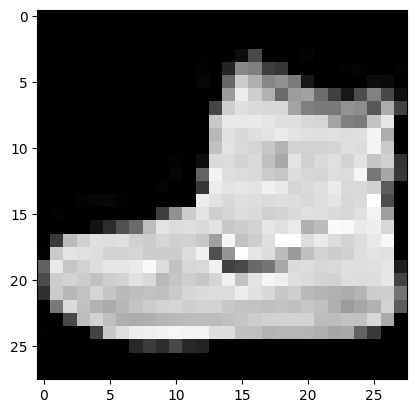

In [8]:
plt.imshow(train_images[0], cmap='gray')

In [9]:
train_labels[0]

np.uint8(9)

In [10]:
class_names = [

    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot']

In [11]:
class_names[train_labels[0]]

'Ankle boot'

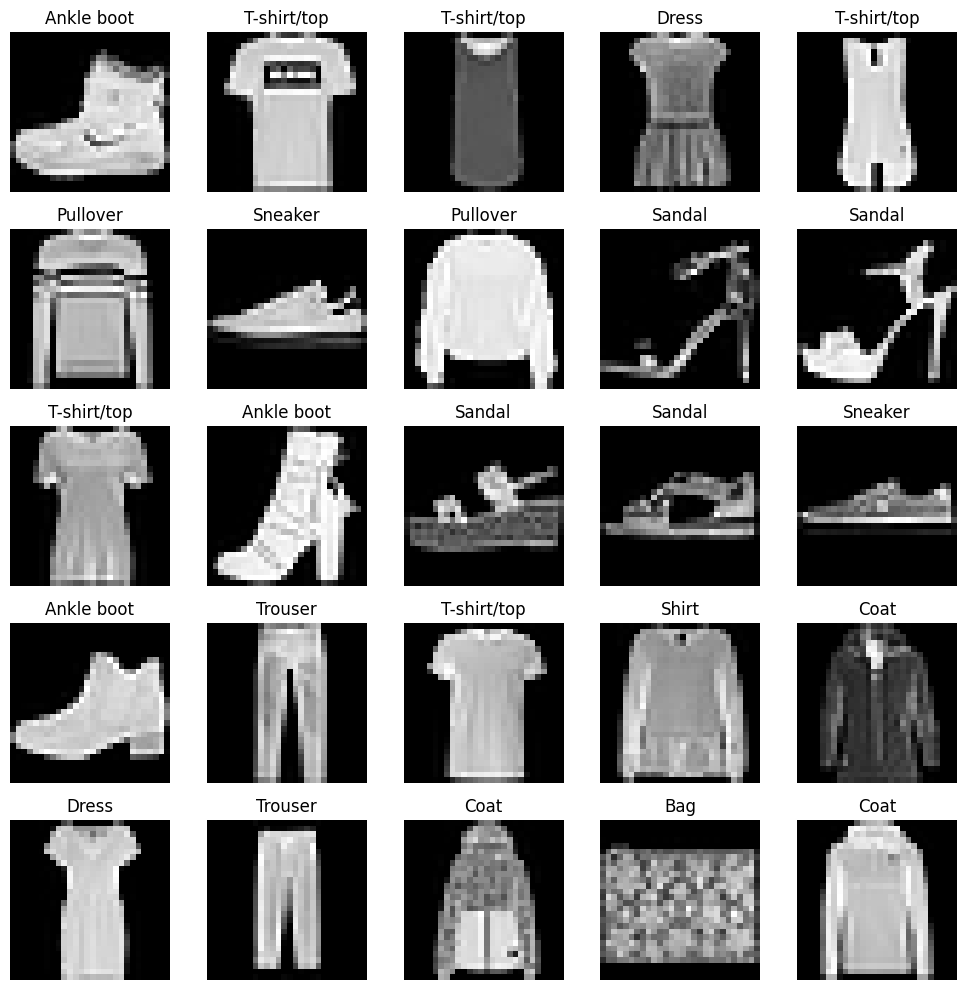

In [12]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(train_images[i], cmap='gray')
  plt.title(class_names[train_labels[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
print(train_images[0])
print(train_images[0].min())
print(train_images[0].max())

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [14]:
from tensorflow.keras.utils import to_categorical
encoded_train_labels = to_categorical(train_labels)
encoded_test_labels = to_categorical(test_labels)
print(encoded_train_labels.shape)
print(encoded_test_labels.shape)

(60000, 10)
(10000, 10)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential([

   Dense(512, activation='relu'),
   Dense(10, activation='softmax')
]
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(

    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)




In [19]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


In [20]:
train_images = train_images.reshape((60000,784))
test_images = test_images.reshape((10000,784))

In [21]:
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')


In [22]:
train_images = train_images / 255
test_images = test_images / 255

In [23]:
# history = model.fit(
#     train_images,
#     train_labels,
#     epochs = 20,
#     batch_size = 128,
#     validation_split = 0.1
# )
history = model.fit(

    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8218 - loss: 0.5155 - val_accuracy: 0.8618 - val_loss: 0.3901
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8634 - loss: 0.3833 - val_accuracy: 0.8600 - val_loss: 0.3718
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8784 - loss: 0.3382 - val_accuracy: 0.8708 - val_loss: 0.3543
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8856 - loss: 0.3116 - val_accuracy: 0.8807 - val_loss: 0.3295
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8953 - loss: 0.2882 - val_accuracy: 0.8803 - val_loss: 0.3383
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8997 - loss: 0.2730 - val_accuracy: 0.8873 - val_loss: 0.3168
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9034 - loss: 0.2614 - val_accuracy: 0.8842 - val_loss: 0.3294
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9081 - loss: 0.2492 - val_accu

In [24]:
print(train_images.shape)
print(train_labels.shape)

print(test_images.shape)
print(test_labels.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [25]:
print(train_labels[:20])

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4]


In [26]:
test_loss, test_accuarcy = model.evaluate(
    test_images,
    test_labels
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8908 - loss: 0.3395


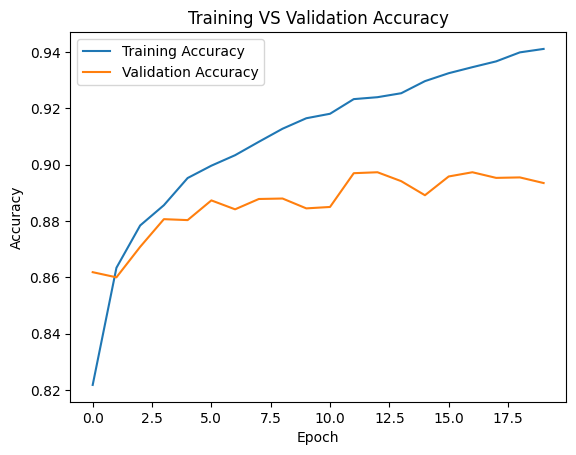

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training VS Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

In [26]:
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend(["Training Loss", "Validation Loss"])
plt.show()